# FakeSight — Stacking Ensemble
**Base learners:** XGBoost, LinearSVC, Logistic Regression  
**Meta-model:** Logistic Regression  
Uses out-of-fold (OOF) predictions to train the meta-model, avoiding data leakage.

In [4]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [5]:
# ── Load & Prepare Data ───────────────────────────────────────────────────────
combined = pd.read_csv("/content/drive/MyDrive/ExAI/combined.csv")

# Combine title + text into one content field
combined["content"] = combined["title"].astype(str) + " " + combined["text"].astype(str)

X = combined["content"]
y = combined["label"]

print(f"Total samples: {len(combined)}")
print(f"Label distribution:\n{y.value_counts()}")

Total samples: 74570
Label distribution:
label
0    41184
1    33386
Name: count, dtype: int64


In [6]:
# ── Train / Test Split ────────────────────────────────────────────────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=23, stratify=y
)

print(f"Train size: {len(X_train_raw)} | Test size: {len(X_test_raw)}")

Train size: 59656 | Test size: 14914


In [7]:
# ── TF-IDF Vectorization ──────────────────────────────────────────────────────
vectorizer = TfidfVectorizer(max_features=8000)
X_train_vec = vectorizer.fit_transform(X_train_raw)
X_test_vec  = vectorizer.transform(X_test_raw)

print(f"Vectorized shape — Train: {X_train_vec.shape} | Test: {X_test_vec.shape}")

Vectorized shape — Train: (59656, 8000) | Test: (14914, 8000)


In [8]:
# ── Define Base Learners ──────────────────────────────────────────────────────
# LinearSVC doesn't support predict_proba natively, so we wrap it
base_models = {
    "XGBoost":  XGBClassifier(n_estimators=100, max_depth=4, eval_metric="logloss", n_jobs=-1, random_state=23),
    "LinearSVC": CalibratedClassifierCV(LinearSVC(random_state=23)),
    "LogReg":   LogisticRegression(max_iter=500, random_state=23)
}

print("Base models defined:", list(base_models.keys()))

Base models defined: ['XGBoost', 'LinearSVC', 'LogReg']


In [9]:
# ── Out-of-Fold (OOF) Predictions ─────────────────────────────────────────────
# We use 5-fold cross-validation to generate OOF predictions for the meta-model.
# This prevents data leakage — the meta-model never sees predictions made on
# data the base models were trained on.

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=23)

y_train_arr = np.array(y_train)

# Containers: one column per base model (probability of class 1)
oof_preds   = np.zeros((X_train_vec.shape[0], len(base_models)))
test_preds  = np.zeros((X_test_vec.shape[0],  len(base_models)))

for col_idx, (name, model) in enumerate(base_models.items()):
    print(f"\nTraining base model: {name}")
    fold_test_preds = np.zeros((X_test_vec.shape[0], N_FOLDS))

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_vec, y_train_arr)):
        X_fold_train = X_train_vec[train_idx]
        y_fold_train = y_train_arr[train_idx]
        X_fold_val   = X_train_vec[val_idx]

        model.fit(X_fold_train, y_fold_train)

        # OOF probability for the validation fold
        oof_preds[val_idx, col_idx] = model.predict_proba(X_fold_val)[:, 1]

        # Test predictions for this fold (averaged later)
        fold_test_preds[:, fold] = model.predict_proba(X_test_vec)[:, 1]
        print(f"  Fold {fold+1}/{N_FOLDS} done")

    # Average test predictions across folds for this base model
    test_preds[:, col_idx] = fold_test_preds.mean(axis=1)

print("\nOOF generation complete!")
print(f"OOF matrix shape:  {oof_preds.shape}")
print(f"Test matrix shape: {test_preds.shape}")


Training base model: XGBoost
  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done

Training base model: LinearSVC
  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done

Training base model: LogReg
  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done

OOF generation complete!
OOF matrix shape:  (59656, 3)
Test matrix shape: (14914, 3)


In [10]:
# ── Train Meta-Model (Logistic Regression) ────────────────────────────────────
meta_model = LogisticRegression(max_iter=500, random_state=23)
meta_model.fit(oof_preds, y_train_arr)

print("Meta-model trained on OOF predictions.")

Meta-model trained on OOF predictions.


In [11]:
# ── Final Evaluation ──────────────────────────────────────────────────────────
y_pred_stack = meta_model.predict(test_preds)

stack_acc = accuracy_score(y_test, y_pred_stack)
print(f"Stacking Ensemble Accuracy: {stack_acc:.4f} ({stack_acc*100:.2f}%)")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_stack, target_names=["Real", "Fake"]))

Stacking Ensemble Accuracy: 0.9088 (90.88%)

Classification Report:
              precision    recall  f1-score   support

        Real       0.91      0.92      0.92      8237
        Fake       0.90      0.89      0.90      6677

    accuracy                           0.91     14914
   macro avg       0.91      0.91      0.91     14914
weighted avg       0.91      0.91      0.91     14914



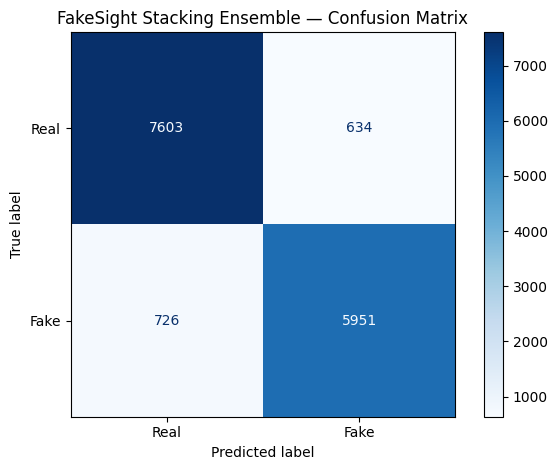

In [12]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_stack)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real", "Fake"])
disp.plot(cmap="Blues")
plt.title("FakeSight Stacking Ensemble — Confusion Matrix")
plt.tight_layout()
plt.show()

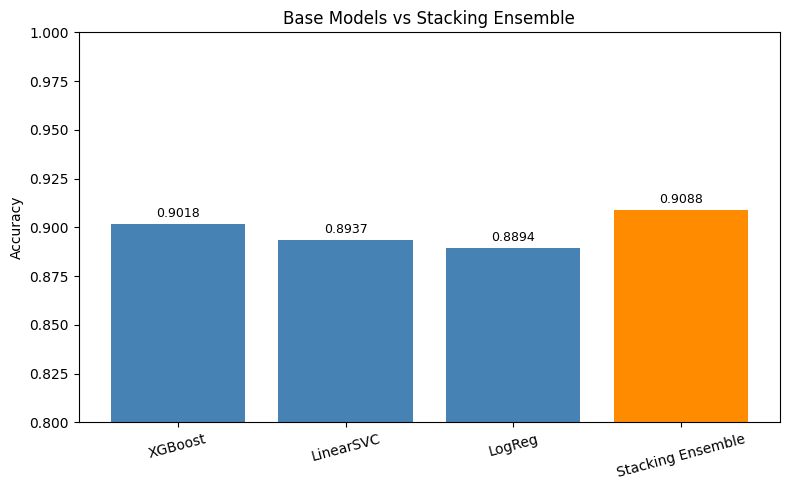


Accuracy Summary:
  XGBoost             : 0.9018
  LinearSVC           : 0.8937
  LogReg              : 0.8894
  Stacking Ensemble   : 0.9088


In [13]:
# ── Compare Base Models vs Ensemble ──────────────────────────────────────────
# Retrain each base model on the FULL training set for a fair final comparison
results = {}

for name, model in base_models.items():
    model.fit(X_train_vec, y_train_arr)
    preds = model.predict(X_test_vec)
    results[name] = accuracy_score(y_test, preds)

results["Stacking Ensemble"] = stack_acc

# Bar chart
colors = ["steelblue"] * (len(results) - 1) + ["darkorange"]
plt.figure(figsize=(8, 5))
bars = plt.bar(results.keys(), results.values(), color=colors)
plt.ylim(0.8, 1.0)
plt.ylabel("Accuracy")
plt.title("Base Models vs Stacking Ensemble")
plt.xticks(rotation=15)
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{val:.4f}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print("\nAccuracy Summary:")
for name, acc in results.items():
    print(f"  {name:<20}: {acc:.4f}")

In [14]:
# ── Save Models & Vectorizer (for XAI next step) ──────────────────────────────
import pickle, os

save_dir = "/content/drive/MyDrive/ExAI/models"
os.makedirs(save_dir, exist_ok=True)

# Retrain base models on full training data before saving
trained_bases = {}
for name, model in base_models.items():
    model.fit(X_train_vec, y_train_arr)
    trained_bases[name] = model

with open(f"{save_dir}/base_models.pkl", "wb") as f:
    pickle.dump(trained_bases, f)

with open(f"{save_dir}/meta_model.pkl", "wb") as f:
    pickle.dump(meta_model, f)

with open(f"{save_dir}/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("Saved: base_models.pkl, meta_model.pkl, tfidf_vectorizer.pkl")
print(f"Location: {save_dir}")

Saved: base_models.pkl, meta_model.pkl, tfidf_vectorizer.pkl
Location: /content/drive/MyDrive/ExAI/models
